In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_data.csv')

In [14]:
stars = ["Star1", "Star2", "Star3", "Star4"]

top_20_stars = (
    df.melt(id_vars="gross_category", value_vars=stars, value_name="Star")
      .dropna(subset=["Star"])
      .groupby("Star")
      .agg(
          Total_Movie_Count=("Star", "size"),
          Low=("gross_category", lambda x: (x == "Low").sum()),
          Moderate=("gross_category", lambda x: (x == "Moderate").sum()),
          High=("gross_category", lambda x: (x == "High").sum()),
          Blockbuster=("gross_category", lambda x: (x == "Blockbuster").sum())
      )
      .query("Total_Movie_Count > 5")
)

top_20_stars["Hit_Coefficient"] = (
    (top_20_stars["High"] + top_20_stars["Blockbuster"])
    / top_20_stars["Total_Movie_Count"]
)

top_20_stars = (
    top_20_stars
    .sort_values("Hit_Coefficient", ascending=False)
    .head(20)
    .reset_index()
)

top_20_stars["Hit_Coefficient"] = top_20_stars["Hit_Coefficient"].map("{:.1%}".format)

top_20_stars

,Star,Total_Movie_Count,Low,Moderate,High,Blockbuster,Hit_Coefficient
0,Daniel Radcliffe,6,0,0,0,6,100.0%
1,Rupert Grint,6,0,0,0,6,100.0%
2,Samuel L. Jackson,6,0,0,1,5,100.0%
3,Tom Hanks,13,0,0,2,11,100.0%
4,Leonardo DiCaprio,11,1,0,1,9,90.9%
5,Matt Damon,11,0,1,0,10,90.9%
6,Harrison Ford,8,0,1,1,6,87.5%
7,Bruce Willis,7,0,1,3,3,85.7%
8,Ian McKellen,7,0,1,0,6,85.7%
9,Russell Crowe,7,0,1,3,3,85.7%


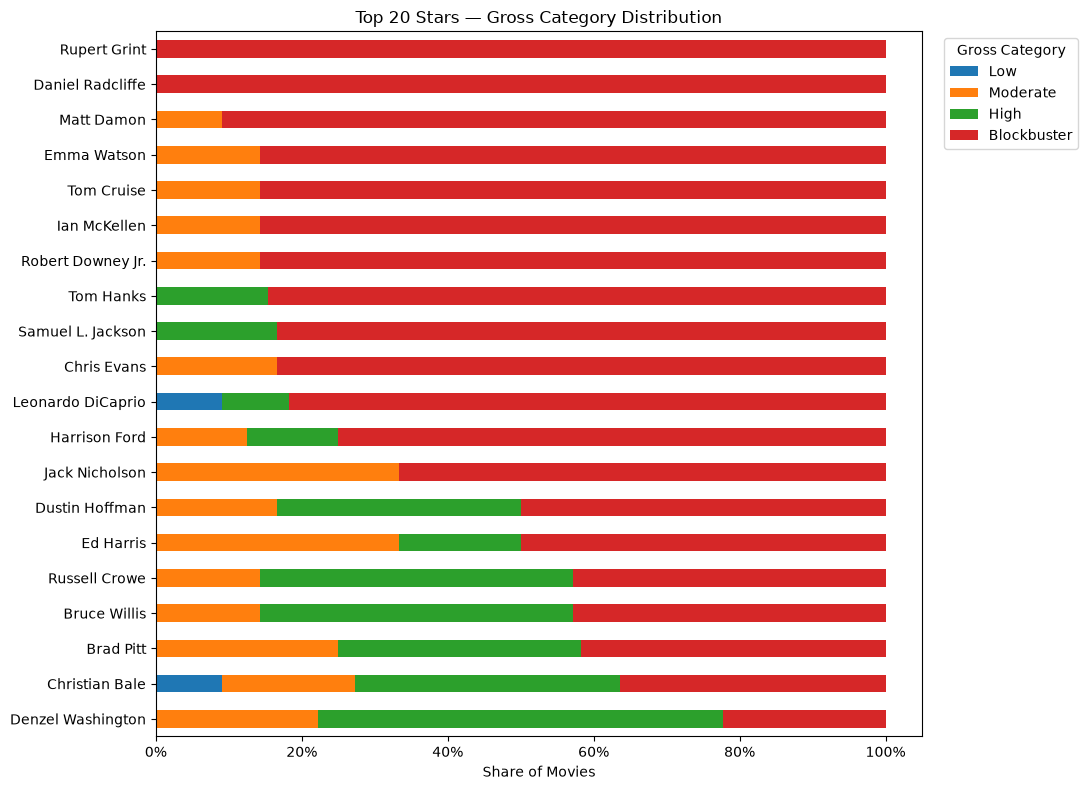

In [16]:
import matplotlib.ticker as mtick

plot_df = top_20_stars.copy()

cols = ["Low", "Moderate", "High", "Blockbuster"]
plot_df[cols] = plot_df[cols].div(
    plot_df["Total_Movie_Count"], axis=0
)

plot_df = plot_df.sort_values("Blockbuster")

ax = plot_df.set_index("Star")[cols].plot(
    kind="barh",
    stacked=True,
    figsize=(11, 8)
)

ax.set_xlabel("Share of Movies")
ax.set_ylabel("")
ax.set_title("Top 20 Stars — Gross Category Distribution")

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.legend(title="Gross Category", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()